In [95]:
import pandas as pd

df_new = pd.read_csv("data/raw/pd_2018_present.csv")
df_old = pd.read_csv('data/raw/pd_2003_2018.csv')

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_1749/2982888874.py:3: DtypeWarning: Columns (18,21,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv("data/raw/pd_2018_present.csv")


In [96]:
print(f"Columns in new: {df_new.columns}")
print(f"Columns in old: {df_old.columns}")


Columns in new: Index(['Row ID', 'Incident Datetime', 'Incident Date', 'Incident Time',
       'Incident Year', 'Incident Day of Week', 'Report Datetime',
       'Incident ID', 'Incident Number', 'CAD Number', 'Report Type Code',
       'Report Type Description', 'Filed Online', 'Incident Code',
       'Incident Category', 'Incident Subcategory', 'Incident Description',
       'Resolution', 'Intersection', 'CNN', 'Police District',
       'Analysis Neighborhood', 'Supervisor District',
       'Supervisor District 2012', 'Latitude', 'Longitude', 'Point',
       'data_as_of', 'data_loaded_at'],
      dtype='object')
Columns in old: Index(['PdId', 'IncidntNum', 'Incident Code', 'Category', 'Descript',
       'DayOfWeek', 'Date', 'Time', 'PdDistrict', 'Resolution', 'Address', 'X',
       'Y', 'location', 'data_loaded_at'],
      dtype='object')


In [97]:
mapping = {
    'IncidntNum': 'Incident Number',
    'Category': 'Incident Category',
    'Date': 'Incident Date',
    'Time': 'Incident Time',
    'PdDistrict': 'Police District',
    'X': 'Longitude',
    'Y': 'Latitude',
    'DayOfWeek':'Incident Day of Week'
}

df_old = df_old.rename(columns=mapping)
df_old = df_old[
            ['Incident Number', 
             'Incident Date', 'Incident Time', 'Incident Day of Week', 'Incident Code', 
             'Incident Category','Police District', 'Latitude', 'Longitude']
            ]

In [98]:
df_old['Row ID'] = df_old.index
# df_old['Incident Datetime'] = df_old['Incident Date'] + " " + df_old['Incident Time']
# df_old['Incident Datetime'] = pd.to_datetime(df_old['Incident Datetime'], format='%m/%d/%Y %H:%M')
# df_new['Incident Datetime'] = pd.to_datetime(df_new['Incident Datetime'], format='%Y/%m/%d %I:%M:%S %p')

df_old["Incident Date"] = pd.to_datetime(
    df_old["Incident Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

df_new["Incident Date"] = pd.to_datetime(
    df_new["Incident Date"],
    format="%Y/%m/%d",
    errors="coerce"
)


In [99]:
# Make Police districts regular letters, not capital
df_old['Police District'].unique, df_new['Police District'].unique

df_new['Police District'] = pd.Categorical(df_new['Police District'])
df_old['Police District'] = pd.Categorical(df_old['Police District'])

df_new['Police District'] = df_new['Police District'].str.upper()
df_old['Police District'].unique(), df_new['Police District'].unique()


df_new['Incident Category'] = pd.Categorical(df_new['Incident Category'])
df_old['Incident Category'] = pd.Categorical(df_old['Incident Category'])

In [100]:
# make both category names capitalized
df_old['Incident Category'] = pd.Categorical(df_old['Incident Category'])
df_new['Incident Category'] = pd.Categorical(df_new['Incident Category'])
df_new["Incident Category"] = df_new["Incident Category"].astype("string").str.lower()
df_old["Incident Category"] = df_old["Incident Category"].astype("string").str.lower()

In [101]:
mappings = {
    # THEFT
    "larceny/theft": "theft",
    "larceny theft": "theft",
    "stolen property": "theft",
    "lost property": "theft",


    # VIOLENCE
    "assault": "assault",
    "robbery": "assault",
    "homicide": "assault",
    "kidnapping": "assault",

    # Vehicle theft
    "motor vehicle theft": "vehicle theft",
    "motor vehicle theft?": "vehicle theft",
    "vehicle theft": "vehicle theft",
    "vehicle misplaced": "vehicle theft",
    "vehicle impounded": "vehicle theft",
    "recovered vehicle": "vehicle theft",

    # DRUGS
    "drug/narcotic": "drug",
    "drug offense": "drug",
    "drug violation": "drug",

    # SEX OFFENSES
    "sex offenses, forcible": "sex_offense",
    "sex offenses, non forcible": "sex_offense",
    "rape": "sex_offense",
    "sex offense": "sex_offense",
    "human trafficking (a), commercial sex acts": "sex_offense",
    "human trafficking (b), involuntary servitude": "sex_offense",
    "human trafficking, commercial sex acts": "sex_offense",
    "prostitution": "sex_offense",

    # WEAPONS
    "weapon laws": "weapons",
    "weapons offense": "weapons",
    "weapons offence": "weapons",
    "weapons carrying etc": "weapons",

    # FRAUD / FINANCIAL
    "forgery/counterfeiting": "fraud",
    "forgery and counterfeiting": "fraud",
    "fraud": "fraud",
    "bad checks": "fraud",
    "bribery": "fraud",
    "extortion": "fraud",

    # ADMIN / OTHER
    "case closure": "other",
    "courtesy report": "other",
    "miscellaneous investigation": "other",
    "other": "other",
    "other miscellaneous": "other",
    "civil sidewalks": "other",
    "secondary codes": "other",
    "trea": "other",
    "trespass": "other",
    "suspicious": "other",
    "suspicious occ": "other",
    "offences against the family and children": "other",
    "fire report": "other",
    "liquor laws": "other",
    "gambling": "other",
    "vandalism": "other",
    "civil sidewalks": "other",
    "fire report": "other",
    "offences against the family and children": "other",
    "vehicle impounded": "other",
    "vehicle misplaced": "other",
    "suspicious": "other",
    "other offences": "other",
    "Other offenses": "other",
}


In [102]:
focus_crime = [
    "arson", "burglary", "theft",
    "drug", "vehicle theft", "weapons",
    "suicide", "missing person", "fraud",
]
focus_cat = pd.CategoricalDtype(categories=focus_crime, ordered=False)

df_old["Incident Category"] = (
    df_old["Incident Category"].astype("string").str.strip().str.lower().replace(mappings)
)
df_new["Incident Category"] = (
    df_new["Incident Category"].astype("string").str.strip().str.lower().replace(mappings)
)

df = pd.concat([df_old, df_new], ignore_index=True)

# categorical makes membership/filtering cheaper and enforces allowed values
df["Incident Category"] = df["Incident Category"].astype(focus_cat)

df = df.loc[df["Incident Category"].notna()]

In [103]:
# df_old['Incident Category'] = df_old['Incident Category'].map(mappings, na_action=None).fillna(df_old['Incident Category'])
# print(df_old['Incident Category'].unique())
# print(df_new['Incident Category'].unique())

# focus_crime = [
#         'arson', 'burglary', 'theft', 
#         'drug offence', 'vehicle theft', 'weapons',
#         'suicide', 'missing person', 'fraud', ]
        
# df = pd.concat([df_old, df_new], axis=0)
# df = df[df['Incident Category'].isin(focus_crime)]
# df.info()

In [104]:
# Now we fetch Incident Numbers where there are duplicates
keys = ['Incident Number', 'Incident Date', 'Incident Time', 'Incident Code', 'Police District']

print("Before cleaning: ", df.shape)
df_cleaned = df[df.duplicated(subset=keys) == False]

print("After cleaning: ", df_cleaned.shape)

# grouped = df_filtered.groupby(['Incident Number', 'Incident Datetime']).filter(lambda x: x.count() != 1)
# grouped

Before cleaning:  (1562239, 29)
After cleaning:  (1527237, 29)


In [105]:
df_cleaned['Incident Year'] = df_cleaned['Incident Date'].dt.year
df_cleaned = df_cleaned.loc[df_cleaned['Incident Year'] != 2026]

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_1749/1498467661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Incident Year'] = df_cleaned['Incident Date'].dt.year


In [106]:
df_cleaned.groupby(['Incident Year', 'Incident Category']).size().unstack()

/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_1749/545025326.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cleaned.groupby(['Incident Year', 'Incident Category']).size().unstack()


Incident Category,arson,burglary,theft,drug,vehicle theft,weapons,suicide,missing person,fraud
Incident Year,,,,,,,,,
2003,286,6013,26961,9784,15276,1196,93,2022,5792
2004,274,6721,24965,9792,17816,1174,102,2208,5195
2005,229,7051,25754,8444,18103,1289,79,2196,4866
2006,240,6967,27779,8943,8347,1246,85,2376,5050
2007,241,5422,26104,10360,7428,1245,111,2361,5087
2008,245,5650,26126,11456,6873,1357,100,2351,5177
2009,221,5366,26059,11771,5824,1367,83,2075,4903
2010,204,4942,24861,9036,4944,1243,82,3140,3896
2011,193,4927,26377,6802,5431,1184,76,3387,3684


In [107]:
df_cleaned.to_csv('data/processed/cleaned_2003_present.csv')

In [108]:
df_plot = (
    df_cleaned[['Incident Year', 'Incident Category']]
        .groupby(['Incident Year', 'Incident Category']).size()
        .unstack('Incident Category', fill_value=0)
        .sort_index()
)
df_plot


/var/folders/7z/72trz_6j2ss4z5yp7pd0jr_00000gn/T/ipykernel_1749/8144582.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Incident Year', 'Incident Category']).size()


Incident Category,arson,burglary,theft,drug,vehicle theft,weapons,suicide,missing person,fraud
Incident Year,,,,,,,,,
2003,286,6013,26961,9784,15276,1196,93,2022,5792
2004,274,6721,24965,9792,17816,1174,102,2208,5195
2005,229,7051,25754,8444,18103,1289,79,2196,4866
2006,240,6967,27779,8943,8347,1246,85,2376,5050
2007,241,5422,26104,10360,7428,1245,111,2361,5087
2008,245,5650,26126,11456,6873,1357,100,2351,5177
2009,221,5366,26059,11771,5824,1367,83,2075,4903
2010,204,4942,24861,9036,4944,1243,82,3140,3896
2011,193,4927,26377,6802,5431,1184,76,3387,3684


In [109]:
df_plot.index

Index([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='Incident Year')

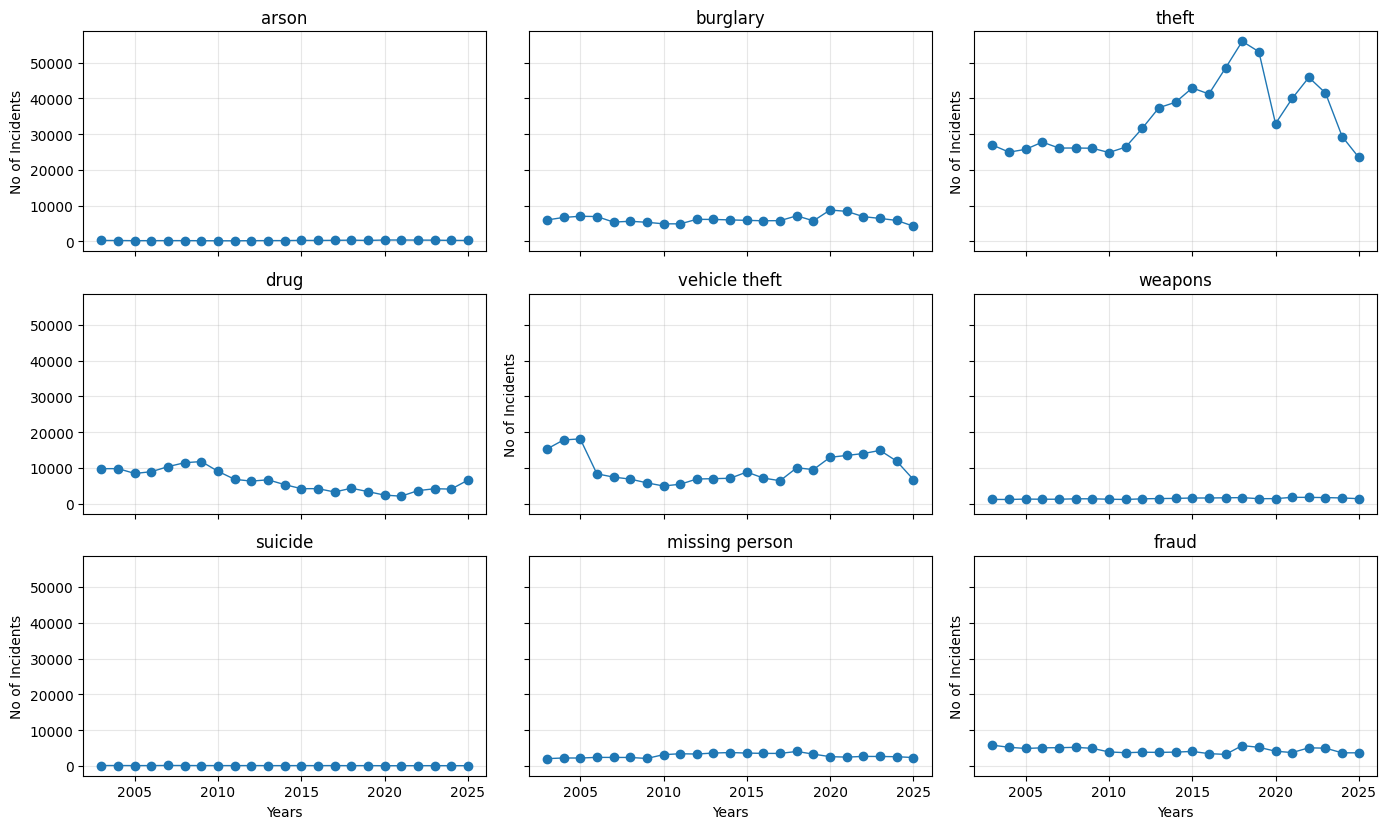

In [110]:
import matplotlib.pyplot as plt
import numpy as np
import math

# plot
cols = df_plot.columns
years = df_plot.index

labels =[c[1] if isinstance(c, tuple) else str(c) for c in cols]
n = len(labels)

# Setup
n = len(labels)
ncols = 3
nrows = math.ceil(n/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows), sharex=True, sharey=True)
axes = axes.ravel()  # make it 1D so we can index easily

# Plot for each type of crime
for ax, col, label in zip(axes, cols, labels):
       ax.plot(years, df_plot[col],marker="o", linewidth=1)
       ax.set_title(label)
       ax.grid(True, alpha=0.3)
       
for ax in axes[::2]:
       ax.set_ylabel('No of Incidents')
       
for ax in axes[6:]:
       ax.set_xlabel('Years')
       
fig.tight_layout()
       
plt.show()